In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.data import DataLoader
from halide_gnn_cost_model.data import PipelineDataset
from pathlib import Path

/Users/fangjun/Documents/stanford/cs224w/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
dataset = PipelineDataset(Path("../resources/pipelines"))
data = dataset[0]  # Get the first pipeline graph
print(data.metadata)

1lines [00:00, 2164.24lines/s]
1lines [00:00, 30393.51lines/s]

<bound method HeteroData.metadata of HeteroData(
  y=[5],
  function={ x=[4, 1] },
  ast_node={ x=[26, 1] },
  loop_level={ x=[16, 1] },
  (function, called_by, function)={ edge_index=[2, 4] },
  (ast_node, child_of, ast_node)={ edge_index=[2, 22] },
  (ast_node, is_expr_of, function)={ edge_index=[2, 4] },
  (loop_level, child_of, loop_level)={ edge_index=[2, 15] },
  (function, schedule_at, loop_level)={ edge_index=[2, 4] }
)>


In [3]:
# Train/test split
num_train = int(0.8 * len(dataset))
train_dataset, test_dataset = random_split(dataset, [num_train, len(dataset) - num_train])
len(train_dataset), len(test_dataset)

(802, 201)

In [4]:
ast_embedding = nn.Embedding(num_embeddings=len(dataset.ast_vocab), embedding_dim=64)
sched_embedding = nn.Embedding(num_embeddings=len(dataset.sched_vocab), embedding_dim=32)

In [5]:
data["ast_node"].x = ast_embedding(data["ast_node"].x.squeeze())
data["loop_level"].x = sched_embedding(data["loop_level"].x.squeeze())

In [6]:
class PipeGCN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, num_layers=2):
        super(PipeGCN, self).__init__()
        self.convs = torch.nn.ModuleList()
        conv = SAGEConv(-1, hidden_channels, aggr="add")
        conv.reset_parameters()
        self.convs.append(conv)
        for _ in range(num_layers - 2):
            conv = SAGEConv(-1, hidden_channels, aggr="add")
            conv.reset_parameters()
            self.convs.append(conv)
        conv = SAGEConv(-1, out_channels, aggr="add")
        conv.reset_parameters()
        self.convs.append(conv)

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

In [7]:
gcn = PipeGCN(hidden_channels=32, out_channels=32, num_layers=2)
gcn = to_hetero(gcn, data.metadata(), aggr="sum")

/Users/fangjun/Documents/stanford/cs224w/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()


In [8]:
class PipelineModel(torch.nn.Module):
    def __init__(self, gnn, out_channels, num_runtime):
        super(PipelineModel, self).__init__()
        self.ast_embedding = nn.Embedding(num_embeddings=len(dataset.ast_vocab), embedding_dim=64)
        torch.nn.init.xavier_uniform_(self.ast_embedding.weight)
        self.sched_embedding = nn.Embedding(num_embeddings=len(dataset.sched_vocab), embedding_dim=32)
        torch.nn.init.xavier_uniform_(self.sched_embedding.weight)
        self.function_gnn = gnn
        self.pipeline_lin = torch.nn.Linear(out_channels, num_runtime)
        torch.nn.init.xavier_uniform_(self.pipeline_lin.weight)

    def forward(self, data, ptr=None):
        data["ast_node"].x = self.ast_embedding(data["ast_node"].x.squeeze())
        data["loop_level"].x = self.sched_embedding(data["loop_level"].x.squeeze())
        x_dict = data.x_dict
        edge_index_dict = data.edge_index_dict
        out = self.function_gnn(x_dict, edge_index_dict)
        # Get the feature of the pipeline node
        start = 0 if ptr is None else ptr[:-1]
        end = -1 if ptr is None else ptr[1:] - 1
        cum_sum = out["loop_level"].cumsum(dim=0) / 10.0
        pipeline_feat = cum_sum[end] - cum_sum[start]
        # Predict the runtime
        x = self.pipeline_lin(pipeline_feat)
        run_time = torch.exp(x)
        return run_time

In [9]:
model = PipelineModel(gcn, 32, 5)
model

PipelineModel(
  (ast_embedding): Embedding(14, 64)
  (sched_embedding): Embedding(8, 32)
  (function_gnn): GraphModule(
    (convs): ModuleList(
      (0-1): 2 x ModuleDict(
        (function__called_by__function): SAGEConv(-1, 32, aggr=add)
        (ast_node__child_of__ast_node): SAGEConv(-1, 32, aggr=add)
        (ast_node__is_expr_of__function): SAGEConv(-1, 32, aggr=add)
        (loop_level__child_of__loop_level): SAGEConv(-1, 32, aggr=add)
        (function__schedule_at__loop_level): SAGEConv(-1, 32, aggr=add)
      )
    )
  )
  (pipeline_lin): Linear(in_features=32, out_features=5, bias=True)
)

In [10]:
data_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
data_loader

/var/folders/qh/c7l883gn5s548l5w18l25cwc0000gn/T/nix-shell.1p1ENT/ipykernel_47569/1543904277.py:1: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  data_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)


In [11]:
for batch in data_loader:
    print(batch)
    print(model(batch, batch["loop_level"].ptr))
    break

HeteroDataBatch(
  y=[40],
  function={
    x=[43, 1],
    batch=[43],
    ptr=[9],
  },
  ast_node={
    x=[278, 1],
    batch=[278],
    ptr=[9],
  },
  loop_level={
    x=[181, 1],
    batch=[181],
    ptr=[9],
  },
  (function, called_by, function)={ edge_index=[2, 40] },
  (ast_node, child_of, ast_node)={ edge_index=[2, 235] },
  (ast_node, is_expr_of, function)={ edge_index=[2, 43] },
  (loop_level, child_of, loop_level)={ edge_index=[2, 173] },
  (function, schedule_at, loop_level)={ edge_index=[2, 48] }
)
tensor([[ 8.0292,  1.1171,  1.7435,  1.9198,  7.6382],
        [ 4.5786,  1.1564,  1.7754,  2.8685,  3.5982],
        [ 3.3577,  1.3160,  1.6272,  1.9679,  5.5377],
        [ 2.2801,  1.0018,  1.4250,  1.6762,  2.5031],
        [ 4.5425,  1.3131,  1.7730,  1.8160,  6.1647],
        [ 9.8356,  2.9145,  2.6551,  3.4808, 32.6989],
        [ 3.6225,  0.9076,  1.3568,  2.1868,  5.6475],
        [ 2.6467,  0.9721,  1.0809,  1.6587,  1.5265]], grad_fn=<ExpBackward0>)


In [12]:
# Train loop (example)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = torch.nn.L1Loss()

for epoch in range(100):
    model.train()
    total_loss = 0
    for batch in data_loader:
        optimizer.zero_grad()
        pred = model(batch, batch["loop_level"].ptr)
        # Assuming batch.y contains the true runtimes
        loss = criterion(pred.reshape(-1), batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(data_loader)}")

Epoch 0, Loss: 412.60445910161087
Epoch 10, Loss: 408.2834446217754
Epoch 20, Loss: 407.6053557443147
Epoch 30, Loss: 403.22878182288446
Epoch 40, Loss: 412.0567953279703
Epoch 50, Loss: 406.9796523292466
Epoch 60, Loss: 363.21838333583116
Epoch 70, Loss: 385.32205026456626
Epoch 80, Loss: 334.99767824682857
Epoch 90, Loss: 320.04153193105566


# Eval

In [13]:
def average_runtime_error(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for batch in data_loader:
            pred = model(batch, batch["loop_level"].ptr)
            error_rates = torch.abs(pred.reshape(-1) - batch.y) / batch.y
            total_error += torch.mean(error_rates).item()
    return total_error / len(data_loader)

In [14]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, test_loader) * 100:.2f}%")

/var/folders/qh/c7l883gn5s548l5w18l25cwc0000gn/T/nix-shell.1p1ENT/ipykernel_47569/2443107822.py:1: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


Average Runtime Error on Test Set: 415.63%


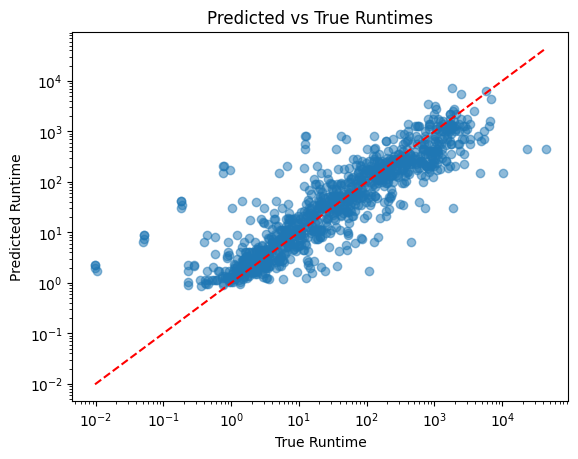

In [15]:
# Plot predicted vs actual runtimes
import matplotlib.pyplot as plt
all_preds = []
all_trues = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        pred = model(batch, batch["loop_level"].ptr)
        all_preds.append(pred.reshape(-1).cpu())
        all_trues.append(batch.y.cpu())
all_preds = torch.cat(all_preds)
all_trues = torch.cat(all_trues)
plt.scatter(all_trues, all_preds, alpha=0.5)
plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Runtime")
plt.ylabel("Predicted Runtime")
plt.title("Predicted vs True Runtimes")
plt.show()

In [16]:
idx = 0  # Index of the sample to inspect
model.eval()
with torch.no_grad():
    sample_data = test_dataset[idx]
    pred_runtime = model(sample_data)
    print(f"Predicted runtime: {pred_runtime}, True runtime: {sample_data.y}")

Predicted runtime: tensor([  1.5477,   5.7253,  26.8241, 130.6483, 357.6865]), True runtime: tensor([   3.1050,   12.7055,   66.3366,  366.5625, 1772.0309])
